In [5]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from BLEanalysis.signals import Signals
from BLEanalysis import utility_methods


In [2]:
%load_ext autoreload
%autoreload 2


# For real version 
Use Norfolk park field trial data


In [8]:

#path_to_data = "March 26 2025 Field Trial/straightpath1/straightpath1.log"
#dev_kit_data = Signals(path_to_data, ['c', 'a', 'b', 'e'], filetype='.log', angleOffset=0)

# key is the name of the route, entry is a tuple of form (log file path, csv file path)
routes = {
    '8': ("bluetooth_experiments/March 26 2025 Field Trial/complexpath8/complexpath8.log",
          "bluetooth_experiments/March 26 2025 Field Trial/complexpath8/2025-03-26_12_09_13_my_iOS_device.csv"),

    '9': ("bluetooth_experiments/March 26 2025 Field Trial/complexpath9/complexpath9.log",
          "bluetooth_experiments/March 26 2025 Field Trial/complexpath9/2025-03-26_12_13_54_my_iOS_device.csv"),
        
    '1': ("bluetooth_experiments/March 26 2025 Field Trial/straightpath1/straightpath1.log",
          "bluetooth_experiments/March 26 2025 Field Trial/straightpath1/2025-03-26_11_37_00_my_iOS_device.csv")
                }

key = '1'
signal_data = routes[key][0]
GPS_File = routes[key][1]

testdata = Signals(signal_data,
                   ['c', 'a', 'b', 'e'], filetype='log',angleOffset=0)
testdata.summarise()

Standardising angles and times (shifting by 0.00 degrees)
Transmitter       Number of records
        a                 4938
        b                 1417
        c                 5180
        e                 2528


Plot locations of the transmitters

[53.368359, 53.368606, 53.367865, 53.369204]
[-1.449715380638564, -1.449716267918566, -1.449712813599501, -1.449701464095627, -1.449687655593472, -1.449672060638987, -1.449653868223425, -1.449641211603521, -1.449637616200308, -1.449620978041457, -1.44960943826687, -1.449594539775268, -1.449586118800825, -1.44957619656003, -1.449571842685956, -1.449566703256749, -1.449550562142802, -1.449539081579581, -1.44952884223339, -1.44951762016764, -1.449505885196613, -1.449495276069111, -1.449488472772797, -1.449476685968104, -1.449469151830546, -1.44945501960488, -1.449442294911975, -1.449431014304749, -1.449420062778532, -1.449407000081406, -1.449392307951417, -1.449379297707613, -1.449367259381619, -1.449351880649887, -1.449338542287528, -1.449323808000165, -1.449306867803551, -1.449290707324283, -1.449278415422928, -1.449262465573183, -1.449250362595524, -1.44923645144675, -1.449221202559451, -1.449207359089815, -1.449197175872685, -1.449186420563016, -1.44917446849748, -1.449156212376665, -

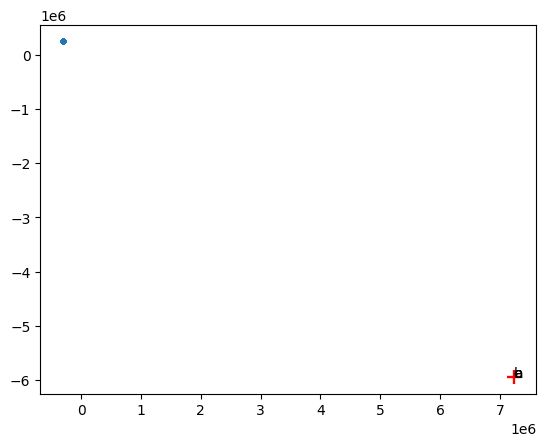

In [ ]:
transmitter_labels = testdata.transmitterIDs
transmitter_latitude = [53.368359, 53.368606, 53.367865, 53.369204]
transmitter_longitude = [-1.450168, -1.448596, -1.448626, -1.449990]

GPSData = utility_methods.LoadFile(GPS_File).split('\n')
path_longitude = []
path_latitude = []
for coord in GPSData[1:-1]:
    coord = coord.split(',')
    path_latitude.append(float(coord[3]))
    path_longitude.append(float(coord[4]))

# project into x, y coordinates and normalise
transmitter_xx, transmitter_yy, path_xx, path_yy = utility_methods.take_multiple_GPS_arrays_project_into_XY_and_normalise(transmitter_latitude, transmitter_longitude, path_latitude, path_longitude)

# plot the transmitters
plt.scatter(transmitter_xx,transmitter_yy, marker='+', s=100, c='red')
for i in range(len(transmitter_labels)):
    plt.text(transmitter_xx[i], transmitter_yy[i], transmitter_labels[i])

# plot the path
plt.scatter(path_xx, path_yy, s=10)




Implementing a Kalman filter:

In [ ]:
theta = np.random.normal(0,0)*10


# Dummy Bayesian Adaptive Design demo using real data

## For dummy version
The bee is at an unknown location, $\theta \in [0,10]^2$.

We can make an observation, $y$ in direction $\xi$. This observation is a triplet of signal strengths at three angles around the actual angle (and transmitter) requested, $\xi$.

We need: $p(y|\theta, \xi)$:

I'll model that here with:

In [59]:
transmitter_locations = np.array([[0,0],[10,0]])

def get_dist_of_y_given_theta_xi(theta,xi):
    """
    Returns the probability distribution of observation y, given theta and xi
    
    theta = location of bee, pass as an Mx2 matrix.
    xi = tuple of id and angle of transmitter
    """
    v = theta - transmitter_locations[xi[0]]
    ang = (np.arctan2(v[:,0],v[:,1]) - xi[1]+np.pi) % (np.pi*2) #angle to bee from the transmitter specified.
    sampleangles = np.array([-0.1,0,0.1])    
    #the expected signal strengths at these sampled angles -- given the bee is actually at 'ang'
    expected_ys = -30+20*np.exp(-(ang[None,:] + sampleangles[:,None]-np.pi)**2/(2*0.1**2)).T 
    return norm(expected_ys,2)

In [60]:
#for example, we will provide two possible locations [5,5] or [6,6], if xi is from transmitter 0, pointing
#at pi/4 radians (so we sample at about 0.68, 0.78 and 0.88 signal measurements)
py = get_dist_of_y_given_theta_xi(np.array([[5,5],[6,6]]),(0,np.pi/4))
py.rvs() #we get three values (the possible measurements at the three angles, asso

array([[-16.42228395, -10.98934258, -18.3285654 ],
       [-15.77753652,  -8.48411661, -17.96860796]])

In [61]:
N = 1000
M = int(np.sqrt(N))

results = []
testangles = np.linspace(0,np.pi*2,16,endpoint=False)
for count,angle in enumerate(testangles):
    print("%d/%d" % (count,len(testangles)),end="\r")
    for transmitter_id in range(2):
        xi = (transmitter_id,angle)
        sum_p = 0
        
        for i in range(N):          
        
            # sample theta:
            theta = np.random.rand(1,2)*10 #possible locations of bees (our prior p(theta))
            # sample y|theta, xi
            py = get_dist_of_y_given_theta_xi(theta,xi)
            y_sample = py.rvs()
            
            #sample theta-prime M times...
            theta_prime = np.random.rand(M,2)*10 #possible locations of bees (our prior p(theta))
            pym = get_dist_of_y_given_theta_xi(theta_prime,xi)
            
            denom = np.mean(np.prod(pym.pdf(y_sample),1)) #compute 1/M * sum p(y_n | theta', xi)
            #divide p(y_n|theta_n,xi) by denom, to give sample
            sum_p += np.sum(py.logpdf(y_sample)) - np.log(denom) #this gives us log p(y|theta,xi) - log p(y|xi) <-- one sample of n for the EIG...
        #print(sum_p / N)
        results.append([sum_p / N, transmitter_id, angle])
results = np.array(results)

Text(0.5, 0, 'Angle / radians')

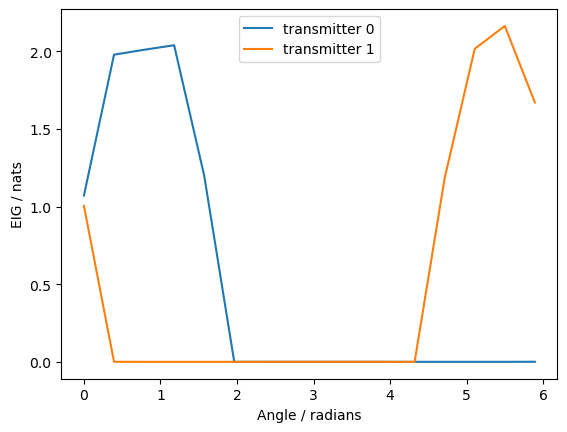

In [62]:
for i in range(2):
    plt.plot(testangles,results[i::2,0],label='transmitter %d' % i)
plt.legend()
plt.ylabel('EIG / nats')
plt.xlabel('Angle / radians')

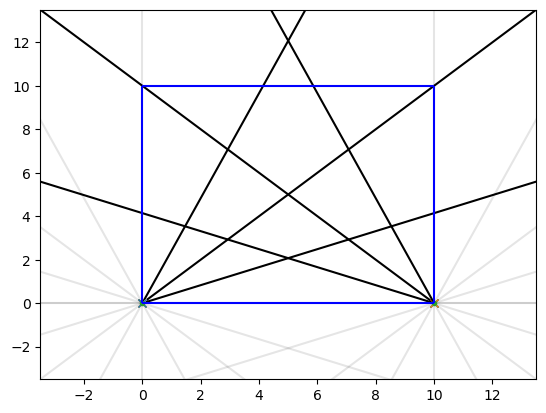

In [63]:
#here I'm just drawing all the choices that are within 0.5nats of the best EIG solution
for res in results:
    chosen = res[0]>np.max(results[:,0])-0.5
    #select = results[maxrowid]
    transmitter_loc = transmitter_locations[int(res[1])]
    ang = -res[2]-np.pi
    vector = 20*np.array([np.sin(ang),-np.cos(ang)])
    
    plt.plot(transmitter_loc[0],transmitter_loc[1],'x')
    plt.plot([transmitter_loc[0],transmitter_loc[0]+vector[0]],[transmitter_loc[1],transmitter_loc[1]+vector[1]],'-k',alpha=1 if chosen else 0.1)

plt.plot(transmitter_locations[:,0],transmitter_locations[:,1],'.')
plt.xlim([-3.5,13.5])
plt.ylim([-3.5,13.5])
plt.vlines([0,10],0,10,color='b')
plt.hlines([0,10],0,10,color='b')